In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import keras_tuner
import tensorflow

from tensorflow import keras
from keras.callbacks import TensorBoard
from keras.callbacks import EarlyStopping
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from keras.layers.normalization import batch_normalization

from sklearn.model_selection import train_test_split

desktop_path = r'C:\Users\Nick Belerman\Desktop\School\Buas\Block C\data/'
laptop_path = r'C:\Users\nickb\OneDrive\Bureaublad\Werk\School\Buas\Block C/'
selected_path = laptop_path
pd.set_option('display.max_columns', 30)
tensorflow.random.set_seed(42)

In [2]:

log_path=r"{}dl_logs\fit".format(selected_path) + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_path, histogram_freq=1)

log_path_eval=r"{}dl_logs\eval".format(selected_path) + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback_eval = TensorBoard(log_dir=log_path_eval, histogram_freq=1)

log_path=r"{}dl_logs\fit_binary_classification".format(selected_path) + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback_bin_class_fit = TensorBoard(log_dir=log_path, histogram_freq=1)

earlystopping = EarlyStopping(monitor='val_loss', patience=3)

Multilayer perceptron (MLP) is a fully connected, feedforward neural network architecture. It consists of one input layer, one or more hidden layers, and one output layer. Each layer consists of units (also called neurons, or nodes).

Each unit is connected to every unit in a neighboring layer, hence fully connected. This is why in Keras these layers are called `Dense`. Information flows from left to right, hence feedforward.

<img src=https://i.imgur.com/BMcpMsH.png width="800">

**Learning objectives**

At the end of this DataLab, you will be able to build MLPs using Keras for the following problem types:

 - Regression
 - Binary classification
 - Multi-class classification
 - Multi-label classification
 
For each type, you will be given a suitable dataset. Then you will:

 - Pre-process the data if needed
 - Create a `Sequential()` model.
 - Compile the model by defining a loss function, an optimizer and the metrics to be calculated.
 - Train the model using the `fit()` method.
 - Test the model using the `predict()` and `evaluate()` methods.
 
 
 **Notebook contents**
 
 1. Regression
 2. Binary classification
 3. Multi-class classification
 4. Multi-label classification
 5. Creative brief

## 1. Regression

**The dataset**

In this task, you will use the diabetes dataset provided by `scikit-learn`.

Please read the dataset documentation before you start:

https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset

In [2]:
from sklearn import datasets
diabetes = datasets.load_diabetes()
X = diabetes.data
y = diabetes.target
names = diabetes.feature_names
Xy_combined = np.concatenate((X, y[:, np.newaxis]), axis=1)
df = pd.DataFrame(Xy_combined,
                  columns=names + ['disease progression'])
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,disease progression
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [3]:

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.33
                                                    )

In [4]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((296, 10), (146, 10), (296,), (146,))

**Task 1.1**

Build an MLP suitable for the diabetes dataset. Use a `Sequential()` model and `Dense` layers from Keras. You are free to pick any number of hidden layers and any number of units per layer as long as it works.  Use suitable activation functions.

**Task 1.2**
Using `model.compile()`, compile the model. Select a suitable optimizer and a suitable loss function. Also include a metric or metrics.

In [27]:


def tune_model_linear_regression(hp):
    model = Sequential()
    model.add(
            Dense(
                units=10,
                activation=hp.Choice('activation', ['selu', 'elu', 'relu', 'linear']),
                input_shape=(10,)
        )
    )
    model.add(
            Dense(
                units=hp.Int('units', min_value=30, max_value=150, step=30),
                activation=hp.Choice('activation', ['selu', 'elu', 'relu', 'linear'])
        )
    )
    if hp.Boolean('dropout'):
        model.add(
                Dropout(
                    rate=hp.Float('rate', min_value=0.1, max_value=0.5, step=0.1)
        )
    )
    model.add(
            Dense(
                units=hp.Int('units', min_value=30, max_value=150, step=30),
                activation=hp.Choice('activation', ['selu', 'elu', 'relu', 'linear'])
        )
    )
    model.add(
            Dense(
                units=1
        )
    )
    learning_rate = hp.Float('lr', min_value=1e-4, max_value=1e-2, sampling='log')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )
    return model

In [33]:
tuner = keras_tuner.RandomSearch(
    hypermodel=tune_model_linear_regression,
    objective='mae',
    max_trials=20,
    executions_per_trial=1,
    overwrite=True,
    directory=selected_path,
    project_name='linear_regression_mlp'
)

In [34]:
tuner.search(
    X_train,
    y_train,
    epochs=50,
    validation_data=(X_test, y_test),
    callbacks=[tensorboard_callback, earlystopping]
)

Trial 20 Complete [00h 00m 09s]
mae: 44.22968673706055

Best mae So Far: 43.98550033569336
Total elapsed time: 00h 04m 34s
INFO:tensorflow:Oracle triggered exit


In [38]:
models = tuner.get_best_models(num_models=2)
#best_hyperparameter = tuner.get_best_hyperparameters(num_trials=1)

best_model = models[0]
best_model.build(input_shape=(10,))


**Task 1.3** Using `model.fit()` Train the model on X_train, y_train and use X_test, y_test as validation data. Pick a suitable number of epochs and batch size.

In [41]:
best_model.fit(X_train, y_train, epochs=500, callbacks=[earlystopping])

Epoch 1/500
10/10 [==============================] - 0s 4ms/step - loss: 3481.3103 - mae: 47.1323
Epoch 2/500
10/10 [==============================] - 0s 4ms/step - loss: 3453.2468 - mae: 46.2714
Epoch 3/500
10/10 [==============================] - 0s 5ms/step - loss: 3182.6743 - mae: 45.4922
Epoch 4/500
10/10 [==============================] - 0s 5ms/step - loss: 3222.0173 - mae: 45.7015
Epoch 5/500
10/10 [==============================] - 0s 4ms/step - loss: 3181.7410 - mae: 44.4616
Epoch 6/500
10/10 [==============================] - 0s 4ms/step - loss: 3359.6135 - mae: 46.7205
Epoch 7/500
10/10 [==============================] - 0s 4ms/step - loss: 3380.7456 - mae: 46.9441
Epoch 8/500
10/10 [==============================] - 0s 5ms/step - loss: 2952.5017 - mae: 42.9744
Epoch 9/500
10/10 [==============================] - 0s 8ms/step - loss: 3182.6003 - mae: 44.8200
Epoch 10/500
10/10 [==============================] - 0s 5ms/step - loss: 3019.0583 - mae: 44.9321
Epoch 11/500
10/10 

**Task 1.4** Evaluate the model using `model.evaluate()`.

In [42]:
best_model.evaluate(X_test, y_test, verbose=3, callbacks=[tensorboard_callback_eval])

[2710.517578125, 41.20800018310547]

**Task 1.5** Get predictions on `X_test`. Plot `y_test` vs. predictions. On the same plot, plot a $x = y$ line. Think about what this line represents.

5/5 [==============================] - 0s 3ms/step


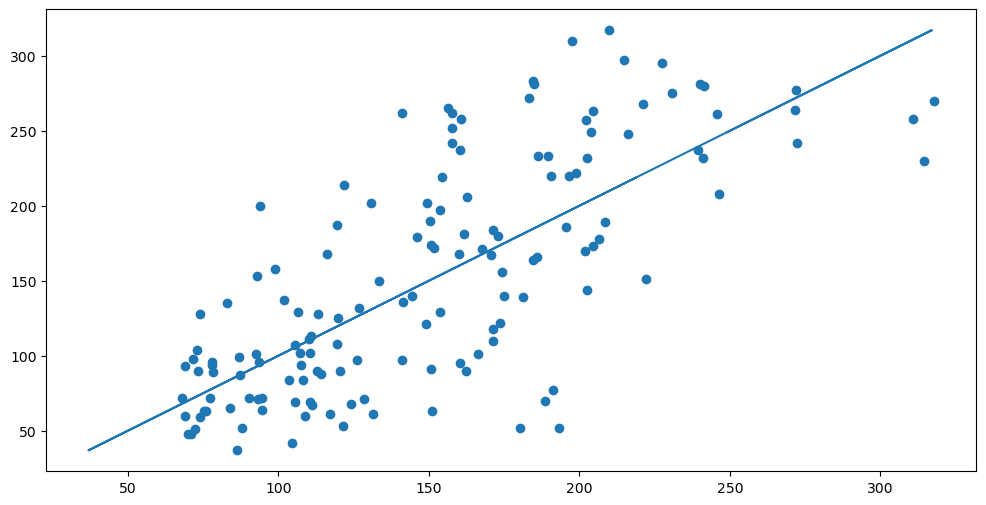

In [43]:
prediction = best_model.predict(X_test)
plt.figure(figsize=(12, 6))
plt.scatter(prediction, y_test)
plt.plot(y_test, y_test)


## 2. Binary classification

**The dataset**

In this task, you will use the breast cancer dataset provided by `scikit-learn`.

Please read the dataset documentation before you start:

https://scikit-learn.org/stable/datasets/toy_dataset.html#breast-cancer-dataset

In [59]:
def min_max_scaler_df(df):
    df_normal = pd.DataFrame()
    for column in df.iloc[:, :-1]:
        df_normal[column] = (df[column]-np.min(df[column]))/(np.max(df[column])-np.min(df[column]))
    return df_normal

,x_1,x_2,x_3,x_4,Parity
0,0.0,0.1,0.2,0.7,0.0
1,0.1,0.0,0.6,0.5,0.0
2,0.3,0.4,0.1,0.7,0.0
3,0.6,0.1,0.4,0.1,0.0
4,0.7,0.4,0.3,0.9,0.0
...,...,...,...,...,...
9995,1.0,0.8,0.7,0.8,0.0
9996,0.6,0.0,0.5,0.8,0.0
9997,0.2,0.6,0.3,0.3,0.0
9998,0.9,0.4,0.9,0.0,0.0


In [189]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
X1 = cancer.data
y1 = cancer.target
names = list(cancer.feature_names)
Xy_combined1 = np.concatenate((X1, y1[:, np.newaxis]), axis=1)
df = pd.DataFrame(Xy_combined1,
                  columns=names + ['Benign'])
X1_normal = min_max_scaler_df(df).to_numpy()
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,...,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Benign
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,...,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0.0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,...,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0.0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,...,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0.0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,...,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0.0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,...,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0.0


In [190]:
from sklearn.model_selection import train_test_split
X_train1, X_test1, y_train1, y_test1 = train_test_split(X1_normal,
                                                        y1,
                                                        test_size=0.33,
                                                       )

X_train1, X_val1, y_train1, y_val1 = train_test_split(X_train1,
                                                      y_train1,
                                                      test_size=0.2,
                                                      )                                                        


In [131]:
X_train1.shape, X_test1.shape, X_val1.shape, y_train1.shape, y_test1.shape, y_val1.shape

((304, 30), (188, 30), (77, 30), (304,), (188,), (77,))

**Task 2.1**

Build an MLP suitable for the breast cancer dataset. Use a `Sequential()` model and `Dense` layers from Keras. You are free to pick any number of hidden layers and any number of units per layer as long as it works. Use suitable activation functions.

**Task 2.2**

Compile the model by selecting a suitable optimizer and a suitable loss function. Also include a metric or metrics.

In [213]:
def tune_model_binary_classification(hp):
    model = Sequential()
    model.add(
            Dense(
                units=30,
                activation=hp.Choice('activation', ['sigmoid', 'elu', 'relu', 'softmax', 'tahn', 'LeakyReLU']),
                input_shape=(30,)
        )
    )
    model.add(
            Dense(
                units=hp.Int('units', min_value=60, max_value=450, step=60),
                activation=hp.Choice('activation', ['sigmoid', 'elu', 'relu', 'softmax', 'tahn', 'LeakyReLU'])
        )
    )
    model.add(
            Dropout(
                rate=hp.Float('rate', min_value=0.01, max_value=0.2, step=0.01)
        )
    )
    model.add(
            Dense(
                units=hp.Int('units', min_value=30, max_value=450, step=30),
                activation=hp.Choice('activation', ['sigmoid', 'elu', 'relu', 'leaky' 'softmax', 'tahn', 'LeakyReLU'])
        )
    )
    model.add(
            Dropout(
                rate=hp.Float('rate', min_value=0.01, max_value=0.2, step=0.01)
        )
    )   
    model.add(
            Dense(
                units=1,
                activation='sigmoid'
        )
    )
    learning_rate = hp.Float('lr', min_value=1e-4, max_value=1e-2, sampling='log')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

In [215]:

tuner = keras_tuner.RandomSearch(
    hypermodel=tune_model_binary_classification,
    objective='val_accuracy',
    max_trials=300,
    executions_per_trial=1,
    overwrite=True,
    directory=selected_path,
    project_name='binary_classification_mlp'
)

In [216]:
tuner.search(
    X_train1,
    y_train1,
    epochs=50,
    validation_data=(X_val1, y_val1),
    callbacks=[tensorboard_callback_bin_class, earlystopping]
)

Trial 300 Complete [00h 00m 01s]

Best val_accuracy So Far: 0.9870129823684692
Total elapsed time: 00h 46m 41s
INFO:tensorflow:Oracle triggered exit


**Task 2.3**

Train the model on X_train, y_train and use X_test, y_test as validation data. Pick a suitable number of epochs and batch size.

In [270]:
models1 = tuner.get_best_models(num_models=2)


best_model1 = models1[0]
best_model1.build(input_shape=(30,))
best_model1.layers[4].rate = 0.1
best_model1.layers[2].rate = 0.1


In [280]:
best_model1.fit(X_train1, y_train1, validation_data=(X_val1, y_val1), epochs=10, batch_size=50)

Epoch 1/10
7/7 [==============================] - 0s 39ms/step - loss: 8.1745e-04 - accuracy: 1.0000 - val_loss: 0.4989 - val_accuracy: 0.9481
Epoch 2/10
7/7 [==============================] - 0s 13ms/step - loss: 0.0015 - accuracy: 1.0000 - val_loss: 0.4239 - val_accuracy: 0.9610
Epoch 3/10
7/7 [==============================] - 0s 14ms/step - loss: 0.0015 - accuracy: 1.0000 - val_loss: 0.4395 - val_accuracy: 0.9610
Epoch 4/10
7/7 [==============================] - 0s 13ms/step - loss: 9.3849e-04 - accuracy: 1.0000 - val_loss: 0.4261 - val_accuracy: 0.9610
Epoch 5/10
7/7 [==============================] - 0s 14ms/step - loss: 5.7345e-04 - accuracy: 1.0000 - val_loss: 0.4200 - val_accuracy: 0.9610
Epoch 6/10
7/7 [==============================] - 0s 13ms/step - loss: 6.2960e-04 - accuracy: 1.0000 - val_loss: 0.4367 - val_accuracy: 0.9610
Epoch 7/10
7/7 [==============================] - 0s 13ms/step - loss: 5.7887e-04 - accuracy: 1.0000 - val_loss: 0.4580 - val_accuracy: 0.9481
Epoch 8

In [159]:
#best_model1.save(r'{}sklearn_breast_cancer_binary_classification_model.h5'.format(selected_path))

In [281]:
best_hyperparameter = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best model architecture: {best_model1.summary()}")

model_best_hps = tuner.hypermodel.build(best_hyperparameter)

for idx, layer in enumerate(model_best_hps.layers):
    print(f'Layer {idx}: {layer.get_config()}')

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 30)                930       
                                                                 
 dense_1 (Dense)             (None, 120)               3720      
                                                                 
 dropout (Dropout)           (None, 120)               0         
                                                                 
 dense_2 (Dense)             (None, 120)               14520     
                                                                 
 dropout_1 (Dropout)         (None, 120)               0         
                                                                 
 dense_3 (Dense)             (None, 1)                 121       
                                                                 
Total params: 19,291
Trainable params: 19,291
Non-traina

**Task 2.4**

Evaluate the model using `model.evaluate()`.

In [283]:
best_model1.evaluate(X_test1, y_test1)

6/6 [==============================] - 0s 4ms/step - loss: 0.1170 - accuracy: 0.9681


[0.11699045449495316, 0.9680851101875305]

**Task 2.5**

Plot the confusion matrix for your trained model on the test set.

6/6 [==============================] - 0s 4ms/step


<AxesSubplot: >

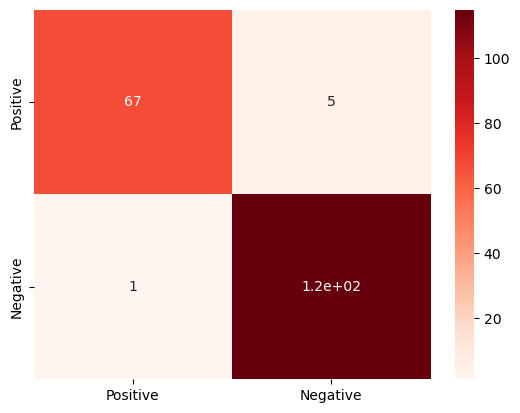

In [284]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
prediction1 = best_model1.predict(X_test1)
prediction1_binary = np.where(prediction1 >= 0.5, 1, 0)

labels = ['Positive', 'Negative']
cm = confusion_matrix(y_test1, prediction1_binary)
sns.heatmap(cm, cmap='Reds', annot=True, xticklabels=labels, yticklabels=labels)

## 3. Multi-class classification

**The dataset**

In this task, you will use the MNIST dataset provided by `keras`.

Please read the dataset documentation before you start:

https://keras.io/api/datasets/mnist/

In [5]:
from keras.datasets import mnist

# Load mnist into variables
(train_images_og, train_labels), (test_images_og, test_labels) = mnist.load_data()

# calling TensorBoard
log_path=r"{}dl_logs\fit_multi_classification".format(selected_path) + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback_multi_class_fit = TensorBoard(log_dir=log_path, histogram_freq=1)



In [6]:
# Check shape of the data
train_images_og.shape, train_labels.shape, test_images_og.shape, test_labels.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

Label: 7


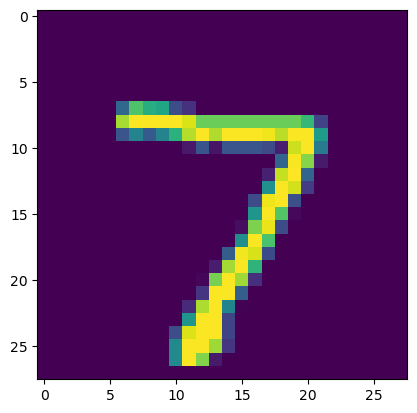

In [26]:
# View random digit
index = np.random.randint(0, 60000)

#plt.imshow(train_images_og[index])
#print('Label:', train_labels[index])

plt.imshow(test_images_og[0])
print('Label:', test_labels[0])

**Task 3.1**

The MLP architecture you will build is given below. 784 input units, two hidden layers with 30 units each, one output layer with 10 units. Notice that X_train shape and input layer shape are not compatible. Similary, y_train and the output layer shape, are not compatible. Preprocess the data to make them compatible. Same is true for the test data.

<img src=https://i.imgur.com/OFNAslJ.png width="500">



In [8]:
# Data preprocessing
# Reshaping train_images & normalizing
train_images = train_images_og.reshape((60000, 28 * 28))
train_images = train_images.astype('float32') / 255

# Reshaping test_images & normalizing
test_images = test_images_og.reshape((10000, 28 * 28))
test_images = test_images.astype('float32') / 255

In [9]:
# Check shape of the data
train_images.shape, test_images.shape, train_labels.shape, test_labels.shape

((60000, 784), (10000, 784), (60000,), (10000,))

**Task 3.2**

Build an MLP suitable for the MNIST dataset. Use a `Sequential()` model and `Dense` layers from Keras. Build the architecture shown in Task 3.1 Use suitable activation functions.

**Task 3.3**

Compile the model by selecting a suitable optimizer and a suitable loss function. Also include a metric or metrics.

In [10]:
def build_digit_classification_model(): 
    model = Sequential() # Init Sequential model
    model.add(Dense(784, 'relu'))  # Add Dense input layer with 784 units, activation relu
    model.add(Dense(10, 'softmax')) # Add Dense output layer with 10 classes, activation softmax
    model.compile(optimizer='rmsprop', # Compiling model
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])
    return model

**Task 3.4**

Train the model on X_train, y_train and use X_test, y_test as validation data. Pick a suitable number of epochs and batch size.

In [11]:
model_digit_classification = build_digit_classification_model()
model_digit_classification.fit(train_images, train_labels, epochs=10, validation_split=0.2, callbacks=[tensorboard_callback_multi_class_fit, earlystopping])

Epoch 1/10
1500/1500 [==============================] - 12s 8ms/step - loss: 0.2079 - accuracy: 0.9382 - val_loss: 0.1116 - val_accuracy: 0.9676
Epoch 2/10
1500/1500 [==============================] - 10s 7ms/step - loss: 0.0916 - accuracy: 0.9728 - val_loss: 0.1103 - val_accuracy: 0.9728
Epoch 3/10
1500/1500 [==============================] - 16s 11ms/step - loss: 0.0663 - accuracy: 0.9810 - val_loss: 0.1005 - val_accuracy: 0.9747
Epoch 4/10
1500/1500 [==============================] - 15s 10ms/step - loss: 0.0501 - accuracy: 0.9861 - val_loss: 0.1062 - val_accuracy: 0.9754
Epoch 5/10
1500/1500 [==============================] - 14s 9ms/step - loss: 0.0387 - accuracy: 0.9893 - val_loss: 0.1023 - val_accuracy: 0.9774
Epoch 6/10
1500/1500 [==============================] - 10s 7ms/step - loss: 0.0301 - accuracy: 0.9915 - val_loss: 0.1196 - val_accuracy: 0.9776
Epoch 7/10
1500/1500 [==============================] - 11s 7ms/step - loss: 0.0247 - accuracy: 0.9935 - val_loss: 0.1205 - val_

**Task 3.5**

Evaluate the model using `model.evaluate()`.

In [12]:
model_digit_classification.evaluate(test_images, test_labels)

313/313 [==============================] - 1s 3ms/step - loss: 0.1172 - accuracy: 0.9801


[0.11716648191213608, 0.9800999760627747]

**Bonus: Task 3.6**

Find the worst prediction. If you struggle with this task, try it later.

In [21]:
pred = model_digit_classification.predict(test_images)
incorrect_indices = [i for i in range(len(test_labels)) if test_labels[i] != np.argmax(pred[i])]
worst_indices = sorted(incorrect_indices, key=lambda i: np.max(pred[i]))

for i in worst_indices:
    print(f"True label: {test_labels[i]}, Predicted label: {np.argmax(pred[i])}")
len(incorrect_indices)

313/313 [==============================] - 2s 7ms/step
True label: 3, Predicted label: 8
True label: 8, Predicted label: 2
True label: 4, Predicted label: 7
True label: 3, Predicted label: 8
True label: 9, Predicted label: 3
True label: 7, Predicted label: 4
True label: 5, Predicted label: 3
True label: 2, Predicted label: 8
True label: 5, Predicted label: 3
True label: 2, Predicted label: 6
True label: 9, Predicted label: 8
True label: 1, Predicted label: 8
True label: 4, Predicted label: 9
True label: 8, Predicted label: 2
True label: 7, Predicted label: 3
True label: 5, Predicted label: 6
True label: 4, Predicted label: 7
True label: 7, Predicted label: 2
True label: 9, Predicted label: 3
True label: 8, Predicted label: 6
True label: 3, Predicted label: 8
True label: 7, Predicted label: 1
True label: 7, Predicted label: 9
True label: 9, Predicted label: 3
True label: 4, Predicted label: 9
True label: 2, Predicted label: 8
True label: 1, Predicted label: 2
True label: 8, Predicted la

199

## 4. Multi-label classification

**The dataset**

In this task you will use a simulated dataset.

You are given 4 random integers ($x_1, x_2, x_3, x_4$) between -5 and 5 ($x_i \in [-5, 5]$). Your task is to develop an MLP that predicts parity and sign of the product of these four numbers ($x_1 \times x_2 \times x_3 \times x_4$).

**Definitions**

In mathematics, parity is the property of an integer of whether it is even or odd.

In mathematics, the sign of a real number is its property of being either positive, negative, or zero.

**Example**

$x_1=-1, x_2=1, x_3=-3, x_4=-5$

$ product = x_1 \times x_2 \times x_3 \times x_4 = -15$

parity of -15 is `odd` and sign of -15 is `negative`.

**Columns**

$x_i$: Integers between -5 (inclusive) and 5 (inclusive).

Parity column: $x_1 \times x_2 \times x_3 \times x_4$ is even (0) or odd (1).

Sign column: $x_1 \times x_2 \times x_3 \times x_4$ is negative (-1), or zero (0) or positive (1).

|$x_1$|$x_2$|$x_3$|$x_4$|$Parity$|$Sign$|
|:--|:--|:--|:--|:--|:--|
|-2|-4|-1|1|0|-1|
|-3|5|-3|3|1|1|
|-4|-2|5|3|0|1|
|-4|0|-5|0|0|0|
|1|1|2|-4|0|-1|
|-1|1|-3|-5|1|-1|

In [27]:
def simulator(n):
    
    # x_i numbers with shape (n, 4)
    X = np.random.randint(-5, 6, size=(n, 4))

    # product of 4 numbers for each row
    # this will be used to calculate labels
    # but this won't be part of the dataset
    product = np.prod(X, axis=1)

    # label 1
    parity_col = product % 2
    parity_col = parity_col.reshape(-1, 1)

    # label 2
    pos = (product > 0)*1
    neg = (product < 0)*-1
    zero = (product == 0)*0
    sign_col = pos + neg + zero
    sign_col = sign_col.reshape(-1, 1)

    # concatenate columns to create the dataset
    dataset = np.concatenate((X, parity_col, sign_col), axis=1)
    
    return dataset

In [28]:
dataset = simulator(n=10000)

In [29]:
df = pd.DataFrame(dataset, columns=['x_1', 'x_2', 'x_3', 'x_4', 'Parity', 'Sign'])
df.head(10)

,x_1,x_2,x_3,x_4,Parity,Sign
0,-5,-4,-3,2,0,-1
1,-4,-5,1,0,0,0
2,-2,-1,-4,2,0,-1
3,1,-4,-1,-4,0,-1
4,2,-1,-2,4,0,1
5,5,-2,1,0,0,0
6,-3,0,-2,2,0,0
7,-2,1,-3,5,0,1
8,4,4,-4,-4,0,1
9,-2,-2,-1,5,0,-1


**Task 4.1**

Use the numpy array `dataset` to create `X` and `y`. Preprocess the data if needed.

In [150]:
from sklearn.preprocessing import LabelBinarizer

X = df.iloc[:, :4]
y_parity = df.iloc[:, -2].to_numpy()
y_sign = df.iloc[:, -1]

lb = LabelBinarizer()
y_sign_encoded = lb.fit_transform(y_sign)
y_combined = pd.DataFrame({'parity':y_parity,
                           '-1':y_sign_encoded[:, 0],
                           '0':y_sign_encoded[:, 1],
                           '1':y_sign_encoded[:, 2]
                           })


In [151]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y_combined,
                                                    test_size=0.33)
X_train, X_val, y_train, y_val = train_test_split(X_train,
                                                  y_train,
                                                  test_size=0.2)


In [152]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape,  X_val.shape, y_val.shape

((5360, 4), (5360, 4), (3300, 4), (3300, 4), (1340, 4), (1340, 4))

**Task 4.2**

Build a MLP suitable for this simulated dataset. Use a `Sequential()` model and `Dense` layers from Keras. Use suitable activation functions.

**Task 4.3**

Compile the model by selecting a suitable optimizer and a suitable loss function. Also include a metric or metrics.

In [127]:
def build_mulit_classification_model(hp):
    model = Sequential()
    model.add(
            Dense(
                units=4,
                activation=hp.Choice('activation', ['sigmoid', 'elu', 'relu', 'softmax', 'tahn', 'LeakyReLU']),
        )
    )
    model.add(
            Dense(
                units=hp.Int('units', min_value=60, max_value=450, step=60),
                activation=hp.Choice('activation', ['sigmoid', 'elu', 'relu', 'softmax', 'tahn', 'LeakyReLU'])
        )
    )
    model.add(
            Dense(
                units=hp.Int('units', min_value=30, max_value=450, step=30),
                activation=hp.Choice('activation', ['sigmoid', 'elu', 'relu', 'leaky' 'softmax', 'tahn', 'LeakyReLU'])
        )
    )
    model.add(
            Dropout(
                rate=hp.Float('rate', min_value=0.01, max_value=0.2, step=0.01)
        )
    )   
    model.add(
            Dense(
                units=4,
                activation='sigmoid'
        )
    )
    learning_rate = hp.Float('lr', min_value=1e-4, max_value=1e-2, sampling='log')
    model.compile(keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

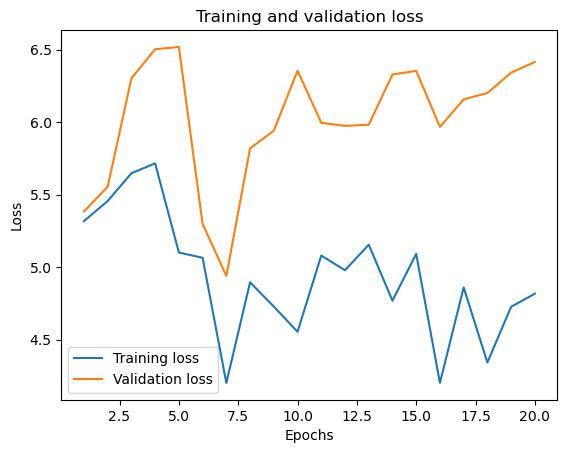

In [364]:
loss_plotter(model_history)

In [156]:
tuner = keras_tuner.RandomSearch(
    hypermodel=build_mulit_classification_model,
    objective='val_accuracy',
    max_trials=100,
    executions_per_trial=1,
    overwrite=True,
    directory=selected_path,
    project_name='multiclass_classification_mlp'
)
tuner.search(
    X_train,
    y_train,
    epochs=20,
    validation_data=(X_val, y_val),


)

Trial 100 Complete [00h 00m 12s]
val_accuracy: 0.43656715750694275

Best val_accuracy So Far: 0.44925373792648315
Total elapsed time: 00h 18m 17s
INFO:tensorflow:Oracle triggered exit


In [157]:
models = tuner.get_best_models(num_models=2)


best_model_multiclass_classification = models[0]

**Task 4.4**

Train the model on X_train, y_train and use X_test, y_test as validation data. Pick a suitable number of epochs and batch size.

In [158]:
#model_multi_classification = build_mulit_classification_model()
best_model_multiclass_classification.fit(X_train, y_train, validation_data=[X_val, y_val], epochs=10)

Epoch 1/10
168/168 [==============================] - 2s 5ms/step - loss: 1.9137 - accuracy: 0.3576 - val_loss: 1.5784 - val_accuracy: 0.4224
Epoch 2/10
168/168 [==============================] - 1s 4ms/step - loss: 2.7752 - accuracy: 0.3330 - val_loss: 1.6880 - val_accuracy: 0.4246
Epoch 3/10
168/168 [==============================] - 1s 4ms/step - loss: 4.1837 - accuracy: 0.3231 - val_loss: 2.8785 - val_accuracy: 0.3560
Epoch 4/10
168/168 [==============================] - 1s 4ms/step - loss: 6.1281 - accuracy: 0.3138 - val_loss: 3.4017 - val_accuracy: 0.4164
Epoch 5/10
168/168 [==============================] - 1s 4ms/step - loss: 8.8800 - accuracy: 0.2985 - val_loss: 2.9513 - val_accuracy: 0.4433
Epoch 6/10
168/168 [==============================] - 1s 4ms/step - loss: 11.5049 - accuracy: 0.3131 - val_loss: 4.4642 - val_accuracy: 0.3731
Epoch 7/10
168/168 [==============================] - 1s 4ms/step - loss: 15.5892 - accuracy: 0.3071 - val_loss: 7.3360 - val_accuracy: 0.3179
Epoc

In [159]:
best_model_multiclass_classification.evaluate(X_test, y_test)

104/104 [==============================] - 0s 3ms/step - loss: 15.1521 - accuracy: 0.3352


[15.152101516723633, 0.3351515233516693]

## 5. Creative Brief

Now it is time to apply what you learned to your creative brief. Build, train and test an MLP model with Keras on your creative brief dataset.

In [4]:
# Loading libraries
import os
import glob
import cv2
from keras.layers import BatchNormalization
from keras.layers import Conv1D, MaxPooling1D, Flatten

In [5]:
def resize_images(image_data, w, h):
    resized_imgs = []
    for img in image_data:
        resized_img = cv2.resize(img, (w, h))
        resized_imgs.append(resized_img)
    
    resized_imgs = np.array(resized_imgs)
    return resized_imgs





In [6]:
def load_images(max_len_class, file_path=str, label1=str, label0=str):
    X = []
    y = []
    images = []
    label = int
    count1 = 0
    count0 = 0
    for fpath in glob.glob(file_path):
        #print(fpath)
        if count0 >= max_len_class and count1 >= max_len_class:
            break
        image = cv2.imread(fpath, cv2.IMREAD_GRAYSCALE)
        images.append(image)
        if any(label in fpath for label in label1) and count1 <= max_len_class:
            #print('Image', fpath, 'has label', label)
            label = 1
            count1 += 1
        elif any(label in fpath for label in label0) and count0 <= max_len_class: 
            #print('Image', fpath, 'has label', label)
            label = 0
            count0 += 1
        else:
            continue
        X.append(image)
        y.append(label)
    

    X = np.array(X)
    y = np.array(y)

    return X, y

In [7]:
def show_data_info(dataset1, dataset2=None):
    
    print(f'Data 1 shape: {dataset1.shape}')
    print(f'Data max value and index: {np.max(dataset1), np.argmax(dataset1)}')
    if dataset2:
        print(f'Data 2 shape: {dataset2.shape}')
        print(f'Data max value and index: {np.max(dataset2), np.argmax(dataset2)}')

In [8]:
def loss_plotter(history):
    epochs = range(1, len(history.history['loss']) + 1)
    plt.plot(epochs, history.history['loss'], label='Training loss')
    plt.plot(epochs, history.history['val_loss'], label='Validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and validation loss')
    plt.legend()
    plt.show()


In [9]:
def accuracy_plotter(history):
    epochs = range(1, len(history.history['loss']) + 1)
    plt.plot(epochs, history.history['accuracy'], label='Training accuracy')
    plt.plot(epochs, history.history['val_accuracy'], label='Validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training and validation accuracy')
    plt.legend()
    plt.show()


In [33]:
file_path = r'C:\Users\nickb\OneDrive\Bureaublad\Werk\School\Buas\Block C\image_subset\eating_drinking\train\*.jpg'

X, y = load_images(file_path=file_path, label1='drinking_', label0='eating_', max_len_class=117)

In [36]:
w = 256
h = 256

X = X.astype('float32') / 255
#X_crop = X[:, 70:-70, 70:-70]
#X_resize = resize_images(X, w=w, h=w)
#X_reshape = X_resize.reshape((len(X_resize), w * h))

In [35]:
show_data_info(dataset1=X), np.count_nonzero(y == 1), np.count_nonzero(y == 0)

Data 1 shape: (235, 256, 256)
Data max value and index: (1.0, 257)


(None, 118, 117)

Label: 1


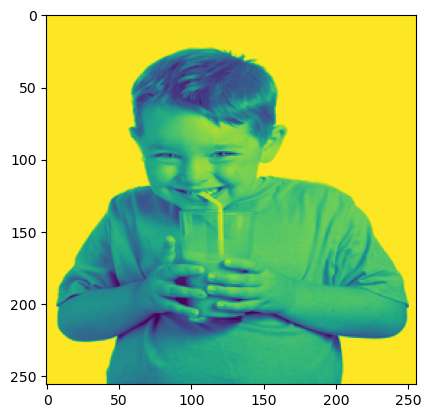

In [39]:
random_index = np.random.randint(0, len(X))


plt.imshow(X[random_index])
print(f'Label: {y[random_index]}')


In [44]:
X_train, X_test = train_test_split(X, test_size=0.3)
y_train, y_test = train_test_split(y, test_size=0.3)


In [45]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((164, 256, 256), (71, 256, 256), (164,), (71,))

In [56]:
def call_existing_code(units=None, activations=None, dropout=None, lr=None, kernel_size=None, pool_size=None, loss=None, optimizers=None):
    model = Sequential()
    model.add(Conv1D(filters=256, kernel_size=(4), activation=activations, input_shape=(h, w)))
    model.add(MaxPooling1D(pool_size=(3)))
    model.add(Flatten())
    model.add(BatchNormalization())
    model.add(Dense(units=units, activation=activations))
    model.add(Dropout(rate=dropout))
    model.add(Dense(1, activation=activations))
    model.compile(optimizer=keras.optimizers.Adam(lr=lr),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

def build_model(hp):
    units = hp.Int('units', min_value=10, max_value=200, step=10)
    kernel_size = hp.Int('kernel_size', min_value=1, max_value=5, step=1)
    pool_size = hp.Int('pool_size', min_value=2, max_value=4, step=1)
    activations = hp.Choice('activations', ['sigmoid', 'elu', 'relu', 'softmax', 'tanh', 'LeakyReLU'])
    dropout =  hp.Float('dropout', min_value=0.1, max_value=0.8, step=0.1)
    lr = hp.Float('lr', min_value=1e-5, max_value=1e-2, sampling='log')
    loss = hp.Choice('loss', ['binary_crossentropy', 'squared_hinge', 'hinge'])
    model = call_existing_code(units, activations, dropout, lr, kernel_size, pool_size, loss)
    return model

In [57]:
log_path1=r"{}dl_logs\search_binary_classification".format(selected_path) + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback_bin_class_search = TensorBoard(log_dir=log_path1, histogram_freq=1, write_graph=False)

In [59]:
hp = keras_tuner.HyperParameters()
tuner = keras_tuner.RandomSearch(
    hypermodel=build_model,
    objective="val_loss",
    max_trials=50,
    executions_per_trial=1,
    overwrite=True,
)

In [46]:
model_tst = call_existing_code()

c:\Users\nickb\anaconda3\envs\TensorFLow\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


In [60]:
tuner.search(X_train, y_train, epochs=40, validation_split=0.2, callbacks=[tensorboard_callback_bin_class_search, earlystopping])

Trial 50 Complete [00h 00m 09s]
val_loss: 0.6862925291061401

Best val_loss So Far: 0.646374523639679
Total elapsed time: 00h 12m 46s
INFO:tensorflow:Oracle triggered exit


In [82]:
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [64]:
models = tuner.get_best_models(num_models=2)
best_model = models[0]

c:\Users\nickb\anaconda3\envs\TensorFLow\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


In [62]:
best_hyperparameter = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best model architecture: {best_model.summary()}")

model_best_hps = tuner.hypermodel.build(best_hyperparameter)

for idx, layer in enumerate(model_best_hps.layers):
    print(f'Layer {idx}: {layer.get_config()}')

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 253, 256)          262400    
                                                                 
 max_pooling1d (MaxPooling1D  (None, 84, 256)          0         
 )                                                               
                                                                 
 flatten (Flatten)           (None, 21504)             0         
                                                                 
 batch_normalization (BatchN  (None, 21504)            86016     
 ormalization)                                                   
                                                                 
 dense (Dense)               (None, 160)               3440800   
                                                                 
 dropout (Dropout)           (None, 160)               0

In [68]:
selected_model = model_tst
model_history = selected_model.fit(X_train, y_train, validation_split=0.2, epochs=50, batch_size=20)
selected_model.evaluate(X_test, y_test)

Epoch 1/50
7/7 [==============================] - 1s 134ms/step - loss: 0.0784 - accuracy: 0.9924 - val_loss: 0.1300 - val_accuracy: 1.0000
Epoch 2/50
7/7 [==============================] - 1s 98ms/step - loss: 0.1276 - accuracy: 0.9618 - val_loss: 0.1312 - val_accuracy: 1.0000
Epoch 3/50
7/7 [==============================] - 1s 96ms/step - loss: 0.0593 - accuracy: 1.0000 - val_loss: 0.1347 - val_accuracy: 1.0000
Epoch 4/50
7/7 [==============================] - 1s 105ms/step - loss: 0.0725 - accuracy: 1.0000 - val_loss: 0.1475 - val_accuracy: 1.0000
Epoch 5/50
7/7 [==============================] - 1s 84ms/step - loss: 0.0809 - accuracy: 0.9924 - val_loss: 0.1023 - val_accuracy: 1.0000
Epoch 6/50
7/7 [==============================] - 1s 84ms/step - loss: 0.0653 - accuracy: 1.0000 - val_loss: 0.0818 - val_accuracy: 1.0000
Epoch 7/50
7/7 [==============================] - 1s 100ms/step - loss: 0.0795 - accuracy: 0.9924 - val_loss: 0.0809 - val_accuracy: 1.0000
Epoch 8/50
7/7 [========

[1.7850466966629028, 0.47887325286865234]

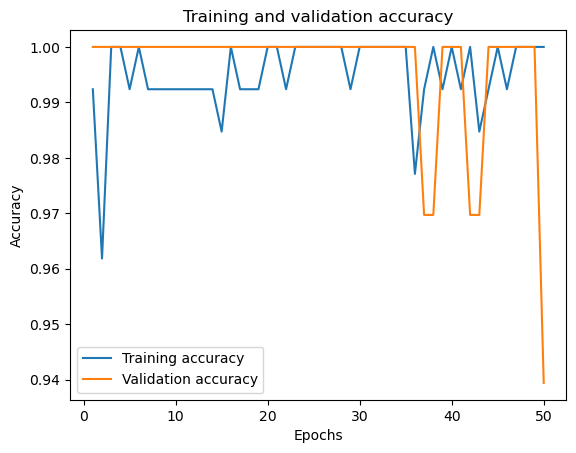

In [69]:
accuracy_plotter(model_history)

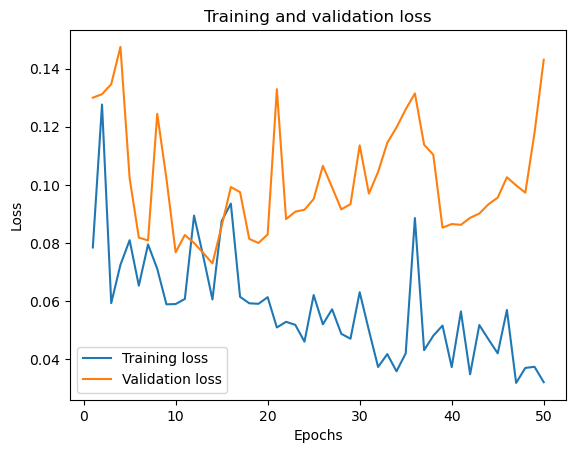

In [70]:
loss_plotter(model_history)